[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DavidNaranjo1237/NATICUSdroid/blob/main/notebooks/03_logistic_regression.ipynb)


# Regresión Logística para la Detección de Malware en Android

Este notebook implementa un modelo de **Regresión Logística** para la clasificación binaria de aplicaciones Android como benignas o maliciosas utilizando el dataset **NATICUSdroid**.

La metodología experimental desarrollada incluye:

- carga del conjunto de datos
- preparación de variables
- partición entrenamiento/prueba
- optimización de hiperparámetros mediante GridSearchCV
- validación cruzada estratificada
- evaluación del modelo con métricas de clasificación
- visualización de matriz de confusión
- análisis mediante curva ROC

El objetivo es: construir un modelo paramétrico base para comparar su desempeño frente a otros modelos de aprendizaje automático.

## 1. Importación de librerías

En esta sección se importan las librerías necesarias para:

- manipulación de datos
- visualización gráfica
- entrenamiento del modelo
- optimización de hiperparámetros
- evaluación del desempeño del clasificador

In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/DavidNaranjo1237/NATICUSdroid.git'
REPO_DIR = Path('/content/NATICUSdroid')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

_bootstrap_dependencies = (
    np,
    pd,
    LogisticRegression,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    GridSearchCV,
    StratifiedKFold,
    Pipeline,
    StandardScaler,
)
print(f'Bootstrap imports loaded: {len(_bootstrap_dependencies)}')


def is_colab() -> bool:
    return 'COLAB_RELEASE_TAG' in os.environ or 'google.colab' in sys.modules


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'prepare_data.py').exists():
            return candidate
    return REPO_DIR if is_colab() else Path.cwd()


repo_root = find_repo_root()
if is_colab() and not (repo_root / 'src' / 'prepare_data.py').exists():
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(repo_root)], check=True)
    else:
        print(f'Repository directory already exists at {repo_root}.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.prepare_data import prepare_dataset

print(f'Repository root: {repo_root}')
print('Imports listos para el entrenamiento de la regresión logística.')


Bootstrap imports loaded: 14
Repository root: c:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid
Imports listos para el entrenamiento de la regresión logística.


## 2. Carga del conjunto de datos

Se cargan los conjuntos de entrenamiento y prueba mediante la función `prepare_dataset()` del proyecto.

De esta manera, la regresión logística utiliza exactamente la misma partición estratificada 70/30, los mismos artefactos procesados y la misma semilla de reproducción que Random Forest, SVM y la red neuronal.


In [2]:
results = prepare_dataset()
summary = results["summary"]
artifacts = results["artifacts"]
X_train = results["X_train"]
X_test = results["X_test"]
y_train = results["y_train"]
y_test = results["y_test"]

print("Resumen del dataset")
print(summary)
print("")
print("Artefactos generados")
for name, value in artifacts.items():
    print(f"{name}: {value}")

print("")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Resumen del dataset
{'rows': 29332, 'columns': 87, 'feature_columns': 86, 'missing_values': 0, 'class_distribution': {'0': 14632, '1': 14700}, 'class_distribution_percent': {'0': 49.8841, '1': 50.1159}}

Artefactos generados
train_features: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\X_train.csv
test_features: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\X_test.csv
train_target: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\y_train.csv
test_target: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\y_test.csv
train_full: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\train.csv
test_full: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\test.csv
metadata: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\split_metadata.json

X_train shape: (20532, 86)
X_test shape: (8800, 86)
y_train shape: (20532,)
y_test shape: (8800,)


## 4. Configuración del modelo y optimización de hiperparámetros

Se construye un pipeline compuesto por:

- **StandardScaler**, para normalizar las variables
- **Regresión Logística**, como modelo de clasificación

Posteriormente se realiza una búsqueda de hiperparámetros mediante **GridSearchCV** usando validación cruzada estratificada de 5 particiones.

Como métrica de optimización se utiliza **F1-score**, debido a que en problemas de detección de malware es importante equilibrar la precisión y la sensibilidad del sistema.

In [3]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

print("Best CV F1-score:")
print(grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters:
{'model__C': 0.1, 'model__solver': 'lbfgs'}
Best CV F1-score:
0.9603261827115256


## 5. Evaluación del modelo final

Una vez identificado el mejor conjunto de hiperparámetros, el modelo se evalúa sobre el conjunto de prueba independiente.

Las métricas calculadas son:

- Accuracy
- Precision
- Recall
- F1-score
- Specificity
- ROC-AUC

Estas métricas permiten evaluar de manera integral el desempeño del clasificador.

In [4]:

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

specificity = tn / (tn + fp)

print("RESULTADOS DE EVALUACIÓN DEL MODELO")
print("====================================\n")

print(f"Accuracy (Exactitud global del modelo): {accuracy_score(y_test, y_pred):.4f}")
print("→ Indica el porcentaje total de predicciones correctas.\n")

print(f"Precision (Precisión de detección de malware): {precision_score(y_test, y_pred):.4f}")
print("→ Mide qué tan confiables son las predicciones positivas del modelo.\n")

print(f"Recall / Sensibilidad (Capacidad de detectar malware): {recall_score(y_test, y_pred):.4f}")
print("→ Indica qué proporción del malware real fue correctamente detectado.\n")

print(f"F1-score (Balance entre precisión y sensibilidad): {f1_score(y_test, y_pred):.4f}")
print("→ Resume el equilibrio entre falsos positivos y falsos negativos.\n")

print(f"Specificity (Capacidad de identificar aplicaciones benignas): {specificity:.4f}")
print("→ Mide qué tan bien el modelo reconoce aplicaciones no maliciosas.\n")

print(f"ROC-AUC (Capacidad discriminativa global): {roc_auc_score(y_test, y_prob):.4f}")
print("→ Evalúa qué tan bien el modelo separa ambas clases en distintos umbrales.")


RESULTADOS DE EVALUACIÓN DEL MODELO

Accuracy (Exactitud global del modelo): 0.9590
→ Indica el porcentaje total de predicciones correctas.

Precision (Precisión de detección de malware): 0.9548
→ Mide qué tan confiables son las predicciones positivas del modelo.

Recall / Sensibilidad (Capacidad de detectar malware): 0.9637
→ Indica qué proporción del malware real fue correctamente detectado.

F1-score (Balance entre precisión y sensibilidad): 0.9593
→ Resume el equilibrio entre falsos positivos y falsos negativos.

Specificity (Capacidad de identificar aplicaciones benignas): 0.9542
→ Mide qué tan bien el modelo reconoce aplicaciones no maliciosas.

ROC-AUC (Capacidad discriminativa global): 0.9888
→ Evalúa qué tan bien el modelo separa ambas clases en distintos umbrales.


## 6. Matriz de confusión

La matriz de confusión permite visualizar detalladamente los resultados de clasificación del modelo, mostrando:

- Verdaderos positivos
- Verdaderos negativos
- Falsos positivos
- Falsos negativos

En el contexto de detección de malware, esta representación es especialmente útil para analizar errores críticos como aplicaciones maliciosas clasificadas incorrectamente como benignas.

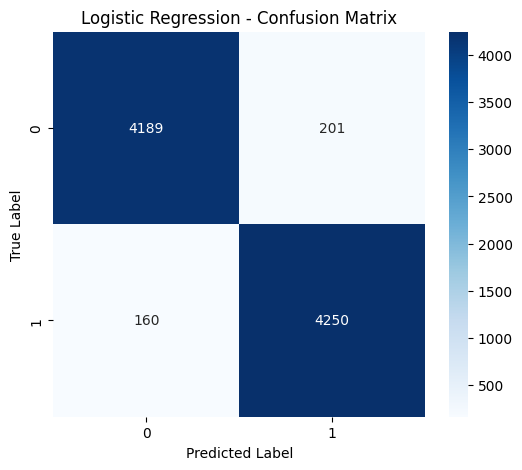

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

## 7. Curva ROC

La curva ROC permite analizar la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos para diferentes umbrales de decisión.

El área bajo la curva (**ROC-AUC**) resume la capacidad discriminativa global del modelo.

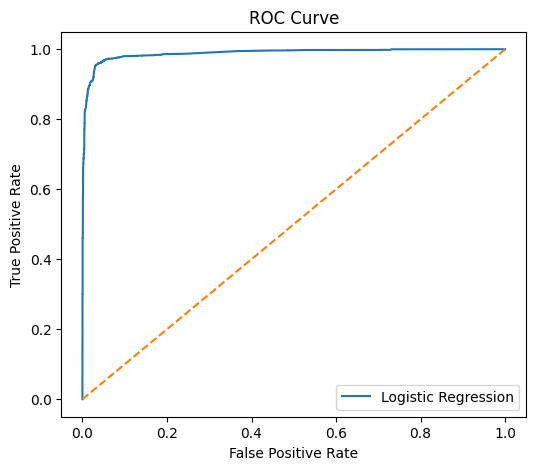

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 8. Sección de gráficas y métricas para el informe

En esta sección se generan las métricas comparativas y las figuras finales del modelo para incorporarlas al informe.


             Modelo Split  Accuracy  Precision   Recall  F1-score  Especificidad  ROC-AUC    IC95 Accuracy          IC95 F1
Regresión logística Train  0.960988   0.956334 0.966278   0.96128       0.955673 0.989670 [0.9585, 0.9637] [0.9586, 0.9640]
Regresión logística  Test  0.958977   0.954842 0.963719   0.95926       0.954214 0.988817 [0.9549, 0.9632] [0.9551, 0.9635]


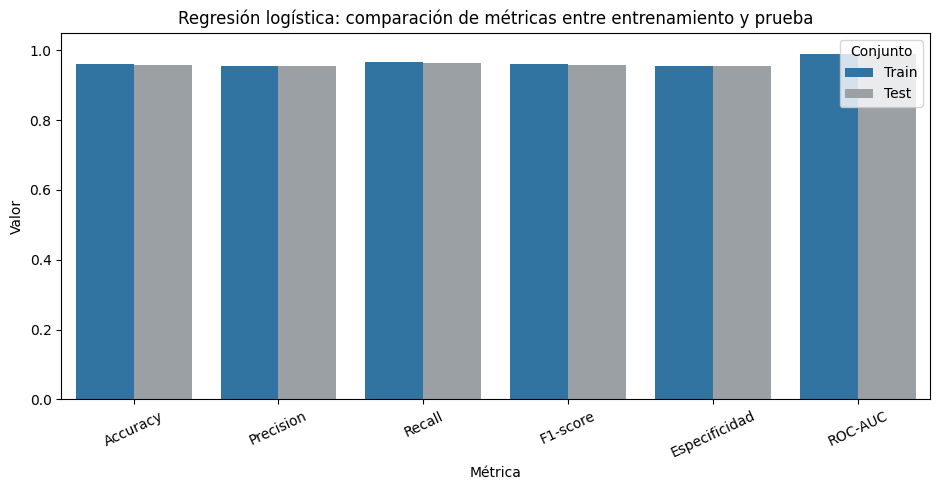

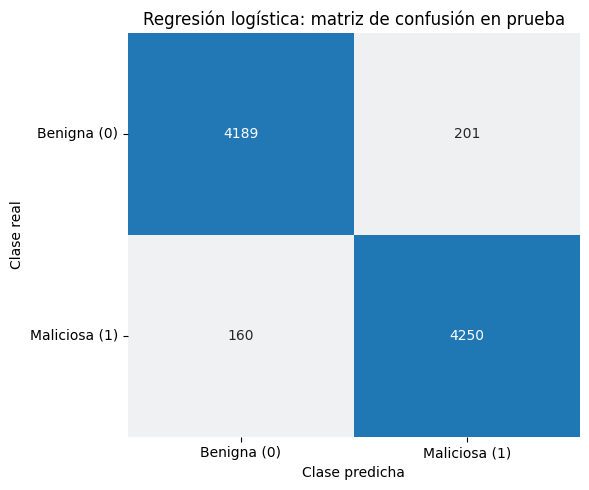

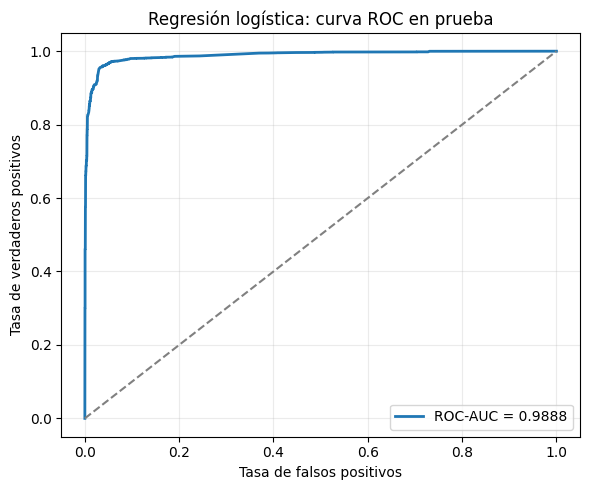

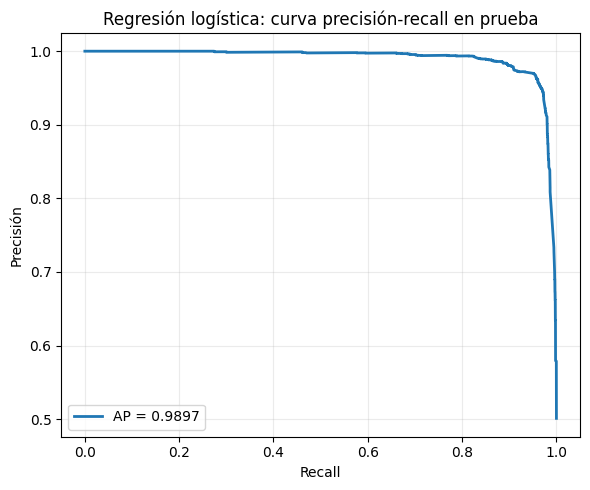

Figuras guardadas en: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\notebooks\Informe_latex\figuras


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import subprocess

try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from src.prepare_data import prepare_dataset


def buscar_raiz_repo(inicio=Path.cwd().resolve()):
    for ruta in [inicio, *inicio.parents]:
        if (ruta / "Informe_latex").exists() and (ruta / "data").exists():
            return ruta
    return inicio


def bootstrap_ci(y_real, y_pred, metric_fn, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)
    n = len(y_real)
    valores = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        valores.append(metric_fn(y_real[idx], y_pred[idx]))
    return np.percentile(valores, [2.5, 97.5])


def calcular_metricas(y_real, y_pred, y_score, nombre_modelo, split):
    cm = confusion_matrix(y_real, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    acc_ci = bootstrap_ci(y_real, y_pred, accuracy_score)
    f1_ci = bootstrap_ci(y_real, y_pred, f1_score)
    return {
        "Modelo": nombre_modelo,
        "Split": split,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, zero_division=0),
        "Recall": recall_score(y_real, y_pred, zero_division=0),
        "F1-score": f1_score(y_real, y_pred, zero_division=0),
        "Especificidad": specificity,
        "ROC-AUC": roc_auc_score(y_real, y_score),
        "IC95 Accuracy": f"[{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]",
        "IC95 F1": f"[{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]",
        "_cm": cm,
    }


def exportar_resultados(metricas_train, metricas_test, y_test, y_pred_test, y_score_test, color_modelo, prefijo_modelo, nombre_modelo):
    repo_root = buscar_raiz_repo()
    fig_dir = repo_root / "Informe_latex" / "figuras"
    fig_dir.mkdir(parents=True, exist_ok=True)

    metricas_estandar = pd.DataFrame([
        {k: v for k, v in metricas_train.items() if k != "_cm"},
        {k: v for k, v in metricas_test.items() if k != "_cm"},
    ])
    print(metricas_estandar.to_string(index=False))
    metricas_estandar.to_csv(fig_dir / f"{prefijo_modelo}_metricas_train_test.csv", index=False)

    metricas_plot = metricas_estandar[["Split", "Accuracy", "Precision", "Recall", "F1-score", "Especificidad", "ROC-AUC"]]
    metricas_largas = metricas_plot.melt(id_vars="Split", var_name="Métrica", value_name="Valor")
    fig, ax = plt.subplots(figsize=(9.5, 5))
    sns.barplot(data=metricas_largas, x="Métrica", y="Valor", hue="Split", palette=[color_modelo, "#9aa0a6"], ax=ax)
    ax.set_ylim(0.0, 1.05)
    ax.set_title(f"{nombre_modelo}: comparación de métricas entre entrenamiento y prueba")
    ax.set_xlabel("Métrica")
    ax.set_ylabel("Valor")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Conjunto")
    fig.tight_layout()
    fig.savefig(fig_dir / f"{prefijo_modelo}_train_test_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    cm = metricas_test["_cm"]
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=sns.light_palette(color_modelo, as_cmap=True), cbar=False, ax=ax)
    ax.set_title(f"{nombre_modelo}: matriz de confusión en prueba")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.set_xticklabels(["Benigna (0)", "Maliciosa (1)"], rotation=0)
    ax.set_yticklabels(["Benigna (0)", "Maliciosa (1)"], rotation=0)
    fig.tight_layout()
    fig.savefig(fig_dir / f"{prefijo_modelo}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_score_test)
    roc_auc = roc_auc_score(y_test, y_score_test)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color=color_modelo, linewidth=2, label=f"ROC-AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(f"{nombre_modelo}: curva ROC en prueba")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(fig_dir / f"{prefijo_modelo}_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    precision_pr, recall_pr, _ = precision_recall_curve(y_test, y_score_test)
    ap = average_precision_score(y_test, y_score_test)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall_pr, precision_pr, color=color_modelo, linewidth=2, label=f"AP = {ap:.4f}")
    ax.set_title(f"{nombre_modelo}: curva precisión-recall en prueba")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precisión")
    ax.legend(loc="lower left")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(fig_dir / f"{prefijo_modelo}_precision_recall_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figuras guardadas en: {fig_dir}")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

COLOR_MODELO = "#1f77b4"
PREFIJO_MODELO = "lg"
NOMBRE_MODELO = "Regresión logística"

results = prepare_dataset()
X_train = results["X_train"]
X_test = results["X_test"]
y_train = results["y_train"]
y_test = results["y_test"]

if "best_model" not in globals():
    best_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.1, solver="lbfgs", max_iter=5000)),
    ])
    best_model.fit(X_train, y_train)

y_pred_train = best_model.predict(X_train)
y_score_train = best_model.predict_proba(X_train)[:, 1]
y_pred_test = best_model.predict(X_test)
y_score_test = best_model.predict_proba(X_test)[:, 1]

metricas_train = calcular_metricas(y_train, y_pred_train, y_score_train, NOMBRE_MODELO, "Train")
metricas_test = calcular_metricas(y_test, y_pred_test, y_score_test, NOMBRE_MODELO, "Test")
exportar_resultados(metricas_train, metricas_test, y_test, y_pred_test, y_score_test, COLOR_MODELO, PREFIJO_MODELO, NOMBRE_MODELO)
